# Week 2

For this I will need 5 frames. 

- I will run inference on 5 frames.
- Testing hypothesis
- Document Gap 1




In [ ]:


import sys
sys.path.append("/Users/niazahmad/Desktop/Research/explainable-video-anomaly-detection/models/aed-mae")

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
from model.model_factory import mae_cvt_patch8

print("="*70)
print("Week 2 - Days 1-2: 5 Frame Experiment")
print("="*70)







In [ ]:
frame_config = {
    'frame_1_normal_105': {
        'video': '01_0025',
        'index': 105,
        'human_description': "Normal scene, no anomaly - typical pedestrian activity",
        'is_anomalous': False,
        'anomaly_type': "Normal",
        'expected_location': "None",
        'expected_size': "N/A",
        'hypothesis': "Model should give LOW score (near 0) - no anomaly present",
    },
    'frame_2_normal_145': {
        'video': '01_0025',
        'index': 145,
        'human_description': "Normal scene, no anomaly - typical pedestrian activity",
        'is_anomalous': False,
        'anomaly_type': "Normal",
        'expected_location': "None",
        'expected_size': "N/A",
        'hypothesis': "Model should give LOW score (near 0) - no anomaly present",
    },
    'frame_3_cyclist_165': {
        'video': '01_0025',
        'index': 165,
        'human_description': "Clear anomaly - cyclist in center of frame",
        'is_anomalous': True,
        'anomaly_type': "Cycling",
        'expected_location': "Center",
        'expected_size': "~80-100px",
        'hypothesis': "Model WILL detect - large, obvious anomaly in center",
    },
    'frame_4_cyclist_edge_190': {
        'video': '01_0025',
        'index': 190,
        'human_description': "Cyclist at left edge + normal walker - challenging case",
        'is_anomalous': True,
        'anomaly_type': "Cycling",
        'expected_location': "Left edge",
        'expected_size': "~60px (partially visible)",
        'hypothesis': "Model might struggle - cyclist at edge, may confuse with normal walker",
    },
    'frame_5_running_125': {
        'video': '01_0027',
        'index': 125,
        'human_description': "Person running + normal walkers - mixed scenario",
        'is_anomalous': True,
        'anomaly_type': "Running",
        'expected_location': "TBD (need to check image)",
        'expected_size': "~60-80px",
        'hypothesis': "Model should detect runner, but may also highlight normal walkers",
    },
}

print(f"✅ Configured {len(frame_config)} frames for testing")
for name, cfg in frame_config.items():
    status = "🔴 ANOMALY" if cfg['is_anomalous'] else "🟢 NORMAL"
    print(f"  {status} | {cfg['video']} Frame {cfg['index']} | {cfg['anomaly_type']}")

In [ ]:
BASE_PATH = "/Users/niazahmad/Desktop/Research/explainable-video-anomaly-detection/SHANGHAI/SHANGHAI_Test/frames"
import os
import cv2
import numpy as np
import torch

def load_frame_triplet(video_id, frame_idx):
    """
    Load prev, curr, next frames for model input
    """

    frame_folder = os.path.join(BASE_PATH, video_id)
    frames = {}

    for offset, name in [(-1, 'prev'), (0, 'curr'), (1, 'next')]:
        idx = frame_idx + offset
        frame_path = os.path.join(frame_folder, f"{idx:03d}.jpg")
        if os.path.exists(frame_path):
            frames[name] = cv2.imread(frame_path)
        else:
            frames[name] = None
        if not os.path.exists(frame_path):
            raise FileNotFoundError(f"Frame {idx} not found at {frame_path}")

        frame = cv2.imread(frame_path)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame_resized = cv2.resize(frame, (320, 160))
        frames[name] = frame_resized


    return frames

# this implementation is without the motion gradient
def preprocess_for_model(frames):
    """
    Here we will convert the frames that are 3 frames in the form of 160 320 3 to  or 1 9 160 320 pytorch expected batch format
    Also we will normalize between -1 and 1
    """

    prev = (frames['prev'].astype(np.float32) - 127.5) / 127.5
    curr = (frames['curr'].astype(np.float32) - 127.5) / 127.5
    next = (frames['next'].astype(np.float32) - 127.5) / 127.5

    stacked_frames = np.concatenate([prev, curr, next], axis=2) # each pixel will have 9 values, if axis 0 then we basically merge the 3 frames, axis 1 is a bit complicated to understand

    stacked_frames = torch.from_numpy(stacked_frames).unsqueeze(0)
  

    stacked_frames = stacked_frames.permute(0, 3, 1, 2)

    return stacked_frames



test_frame = frame_config['frame_1_normal_105']  # Access nested dict

frames = load_frame_triplet(test_frame['video'], test_frame['index'])
input_tensor = preprocess_for_model(frames)
print(input_tensor.shape)
    

            

In [ ]:
# Loading the model

teacher_ckpt = "/Users/niazahmad/Desktop/Research/explainable-video-anomaly-detection/models/aed-mae/experiments/shanghai/checkpoint-best.pth"
student_ckpt = "/Users/niazahmad/Desktop/Research/explainable-video-anomaly-detection/models/aed-mae/experiments/shanghai/checkpoint-best-student.pth"


model = mae_cvt_patch8(
    norm_pix_loss=False,
    img_size=(160, 320),
    use_only_masked_tokens_ab=False,
    abnormal_score_func=["l1", "L1"],
    masking_method="random_masking",
    grad_weighted_loss=True
).float()

device = torch.device("mps")
teacher = torch.load(teacher_ckpt, map_location=device, weights_only=False)["model"]
student = torch.load(student_ckpt, map_location=device, weights_only=False)["model"]

for key in student.keys():
    if "student" in key:
        teacher[key] = student[key]

model.load_state_dict(teacher, strict=False)
model.eval()
model.train_TS = True
model.abnormal_score_func = "L1"

print("Model loaded and ready")

In [ ]:
all_frames = {}
all_rgb = {}

for name, cfg in frame_config.items():
    raw = load_frame_triplet(cfg['video'], cfg['index'])
    tensor = preprocess_for_model(raw)
    all_frames[name] = tensor
    all_rgb[name] = raw['curr']  # the RGB image for visualization
    print(f"Loaded {name}: {tensor.shape}")

print(f"\nAll {len(all_frames)} frames loaded")

In [ ]:
import sys
sys.path.append("/Users/niazahmad/Desktop/Research/explainable-video-anomaly-detection/models/aed-mae")

import os
import cv2
import numpy as np
import torch
from model.model_factory import mae_cvt_patch8

# === Paths ===
BASE_FRAMES = "/Users/niazahmad/Desktop/Research/explainable-video-anomaly-detection/SHANGHAI/SHANGHAI_Test/frames"
BASE_GRADS  = "/Users/niazahmad/Desktop/Research/explainable-video-anomaly-detection/SHANGHAI/SHANGHAI_Test/gradients2"
INPUT_SIZE  = (160, 320)   # (H, W) — from configs
MASK_RATIO  = 0.5
FRAME_STEP  = 3            # official dataset uses direction=±3

teacher_ckpt = "/Users/niazahmad/Desktop/Research/explainable-video-anomaly-detection/models/aed-mae/experiments/shanghai/checkpoint-best.pth"
student_ckpt = "/Users/niazahmad/Desktop/Research/explainable-video-anomaly-detection/models/aed-mae/experiments/shanghai/checkpoint-best-student.pth"

model = mae_cvt_patch8(
    norm_pix_loss=False,
    img_size=INPUT_SIZE,
    use_only_masked_tokens_ab=False,
    abnormal_score_func=["L1", "L1"],
    masking_method="random_masking",
    grad_weighted_loss=True
).float()

device = torch.device("mps")
teacher = torch.load(teacher_ckpt, map_location=device, weights_only=False)["model"]
student = torch.load(student_ckpt, map_location=device, weights_only=False)["model"]
for key in student:
    if "student" in key:
        teacher[key] = student[key]
model.load_state_dict(teacher, strict=False)
model.eval()
model.train_TS = True
model.abnormal_score_func_TS = "L1"   # Shanghai uses L1


# === Data loading — matches test_dataset.py exactly ===

def read_frame_if_exists(folder, frame_no, offset, n_digits, ext=".jpg"):
    """Replicates test_dataset.read_prev_next_frame_if_exists"""
    target_idx = frame_no + offset
    path = os.path.join(folder, str(target_idx).zfill(n_digits) + ext)
    if os.path.exists(path):
        return cv2.imread(path)          # BGR, uint8
    return cv2.imread(os.path.join(folder, str(frame_no).zfill(n_digits) + ext))


def load_single_frame(video_id, frame_idx):
    """
    Replicates test_dataset.__getitem__ exactly.
    Returns: samples (1,9,H,W), grads (1,3,H,W), target (1,4,H,W)
    """
    frame_folder = os.path.join(BASE_FRAMES, video_id)
    grad_folder  = os.path.join(BASE_GRADS, video_id)
    n_digits = 3  # e.g. "105" -> "105.jpg"

    # Current frame (BGR)
    current_img = cv2.imread(os.path.join(frame_folder, f"{str(frame_idx).zfill(n_digits)}.jpg"))

    # Previous and next frames (offset ±3, matching official code)
    previous_img = read_frame_if_exists(frame_folder, frame_idx, -FRAME_STEP, n_digits)
    next_img     = read_frame_if_exists(frame_folder, frame_idx, +FRAME_STEP, n_digits)

    # Stack 3 frames → 9 channels (BGR concat, matching official code)
    img = np.concatenate([previous_img, current_img, next_img], axis=-1)

    # Load precomputed gradient
    gradient = cv2.imread(os.path.join(grad_folder, f"{str(frame_idx).zfill(n_digits)}.jpg"))

    # Resize if needed
    target_hw = (INPUT_SIZE[0], INPUT_SIZE[1])  # (H, W)
    if img.shape[:2] != target_hw:
        img         = cv2.resize(img, (INPUT_SIZE[1], INPUT_SIZE[0]))
        current_img = cv2.resize(current_img, (INPUT_SIZE[1], INPUT_SIZE[0]))
        gradient    = cv2.resize(gradient, (INPUT_SIZE[1], INPUT_SIZE[0]))

    # Build target: current_img (3ch) + zero anomaly mask (1ch)
    mask = np.zeros((img.shape[0], img.shape[1], 1), dtype=np.uint8)
    target = np.concatenate((current_img, mask), axis=-1)  # (H, W, 4)

    # Normalize — BOTH img and target get the same normalization
    img      = img.astype(np.float32)
    gradient = gradient.astype(np.float32)
    target   = target.astype(np.float32)
    img    = (img - 127.5) / 127.5       # → [-1, 1]
    target = (target - 127.5) / 127.5    # anomaly channel becomes -1.0

    # Rearrange to (C, H, W) — matching official swapaxes
    img      = np.swapaxes(img, 0, -1).swapaxes(1, -1)       # (9, H, W)
    target   = np.swapaxes(target, 0, -1).swapaxes(1, -1)     # (4, H, W)
    gradient = np.swapaxes(gradient, 0, 1).swapaxes(0, -1)    # (3, H, W)

    # Add batch dim
    samples = torch.from_numpy(img).unsqueeze(0)        # (1, 9, H, W)
    grads   = torch.from_numpy(gradient).unsqueeze(0)    # (1, 3, H, W)
    targets = torch.from_numpy(target).unsqueeze(0)      # (1, 4, H, W)

    return samples, grads, targets


# === Run inference — matches inference.py exactly ===

frame_config = {
    'frame_1_normal_105':      {'video': '01_0025', 'index': 105},
    'frame_2_normal_145':      {'video': '01_0025', 'index': 145},
    'frame_3_cyclist_165':     {'video': '01_0025', 'index': 165},
    'frame_4_cyclist_edge_190':{'video': '01_0025', 'index': 190},
    'frame_5_running_125':     {'video': '01_0027', 'index': 125},
}

all_scores_teacher = {}
all_scores_st = {}
all_anomaly_maps = {}
all_recon_frames = {}

with torch.no_grad():
    for name, cfg in frame_config.items():
        samples, grads, targets = load_single_frame(cfg['video'], cfg['index'])

        # Single forward pass — identical to inference.py line 38
        _, pred_teacher, mask, scores = model(
            samples, targets=targets, grad_mask=grads, mask_ratio=MASK_RATIO
        )

        score_st      = scores[0].item()   # |teacher - student| discrepancy
        score_teacher  = scores[1].item()   # |target - teacher| reconstruction error

        # Unpatchify to get spatial outputs
        recon_t = model.unpatchify(pred_teacher)
        predicted_anomaly_map = recon_t[0, 3, :, :].cpu()  # channel 3 = anomaly map
        recon_frame           = recon_t[0, :3, :, :].cpu()  # channels 0-2 = reconstructed frame

        all_scores_teacher[name] = score_teacher
        all_scores_st[name]      = score_st
        all_anomaly_maps[name]   = predicted_anomaly_map
        all_recon_frames[name]   = recon_frame

        # For Shanghai, official code uses only score_teacher (inference.py line 56)
        print(f"{name}: score_teacher={score_teacher:.4f}  score_st={score_st:.4f}")

print("\nDone")

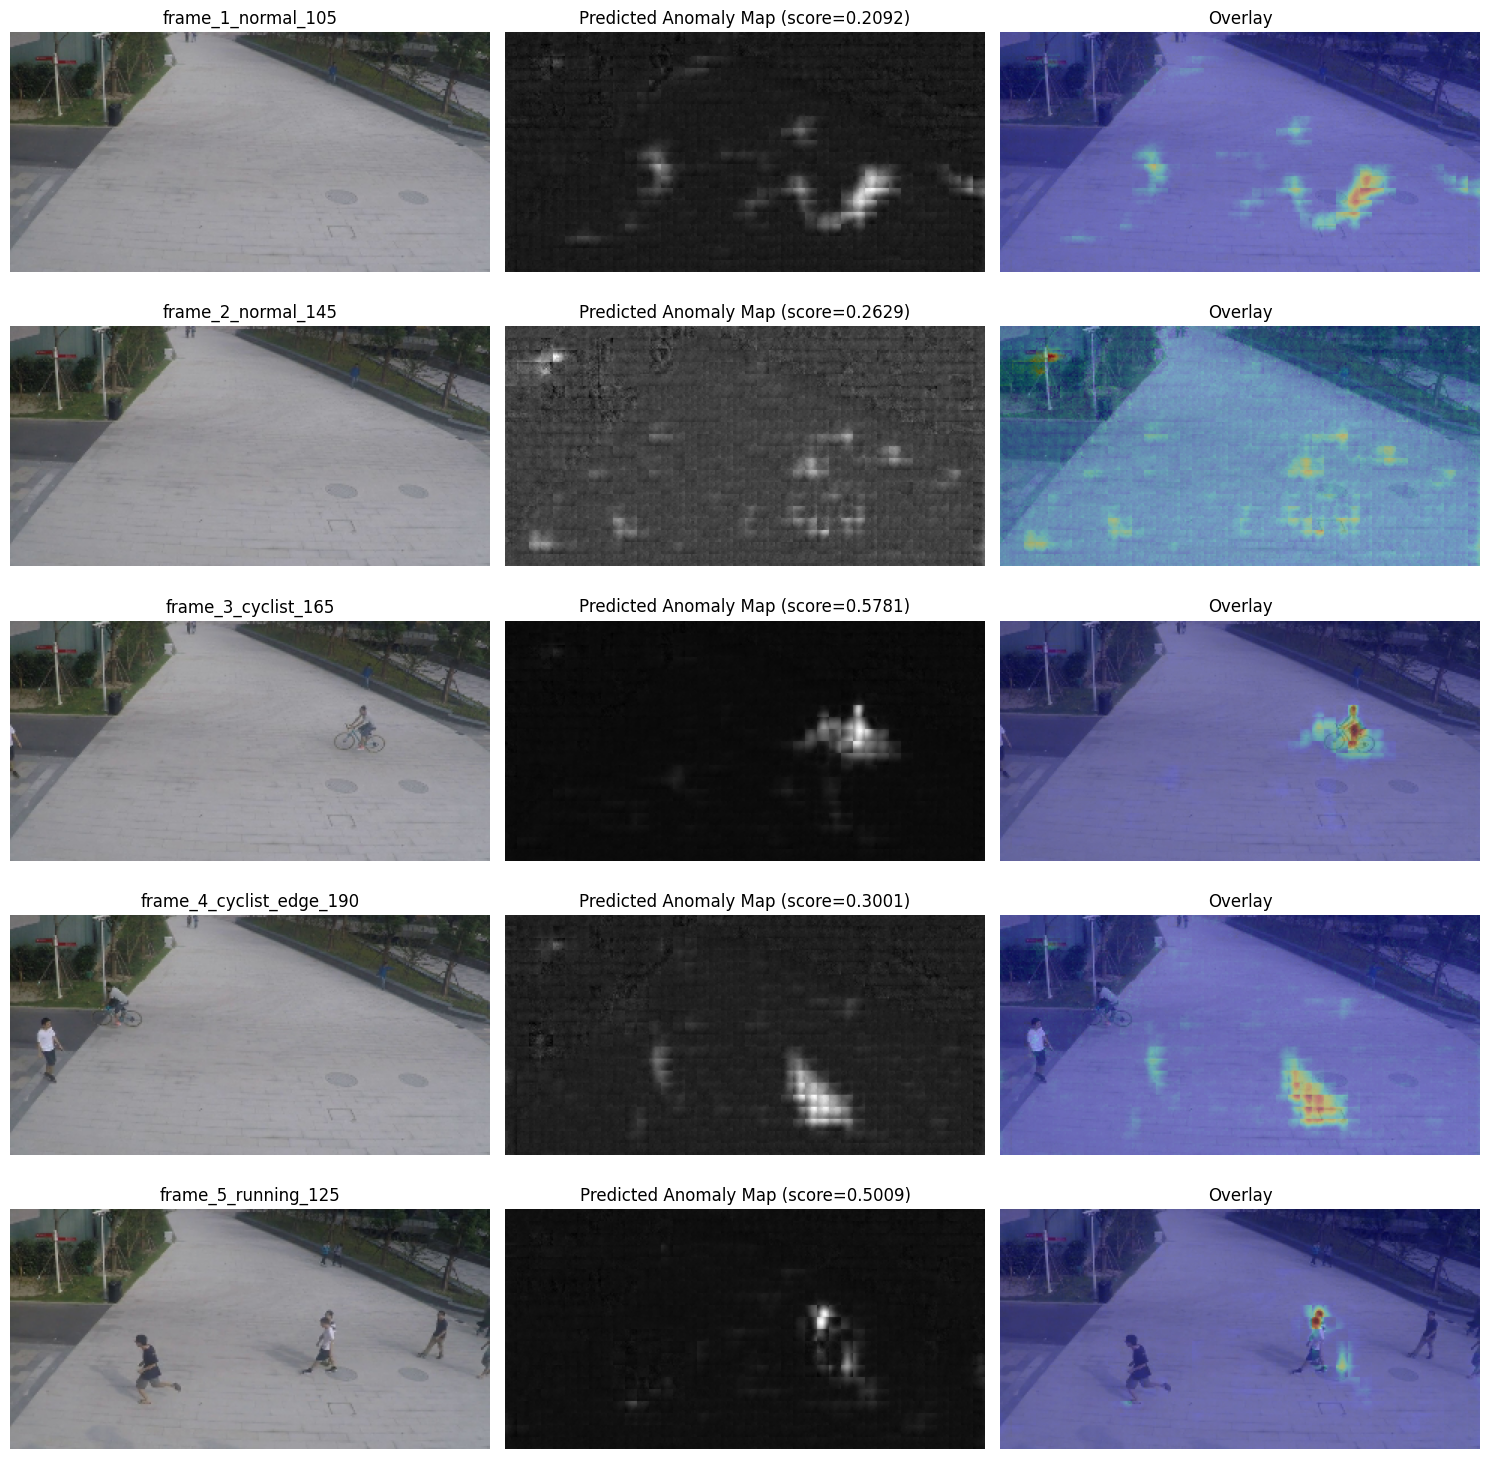

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, axes = plt.subplots(len(frame_config), 3, figsize=(15, 3*len(frame_config)))

for i, (name, cfg) in enumerate(frame_config.items()):
    # Original frame (load as RGB for display)
    frame_path = os.path.join(BASE_FRAMES, cfg['video'], f"{cfg['index']:03d}.jpg")
    orig = cv2.cvtColor(cv2.imread(frame_path), cv2.COLOR_BGR2RGB)
    orig = cv2.resize(orig, (INPUT_SIZE[1], INPUT_SIZE[0]))

    # Predicted anomaly map (channel 3 of teacher output)
    amap = all_anomaly_maps[name].numpy()

    axes[i, 0].imshow(orig)
    axes[i, 0].set_title(f"{name}")

    axes[i, 1].imshow(amap, cmap='gray')
    axes[i, 1].set_title(f"Predicted Anomaly Map (score={all_scores_teacher[name]:.4f})")

    axes[i, 2].imshow(orig)

    amap_norm = (amap - amap.min()) / (amap.max() - amap.min() + 1e-8)
    axes[i, 2].imshow(amap_norm, cmap='jet', alpha=0.3)
    axes[i, 2].set_title("Overlay")

    for ax in axes[i]:
        ax.axis('off')

plt.tight_layout()
plt.show()